# 03 — NDVI Regression: What Drives Farm Canopy Health?

Predict `ndvi_median` separately for **Kona** and **Kaʻu** farms, then compare
which features matter in each region.

**Hypothesis:** In Kaʻu (dry, 750 mm/yr) moisture proxies dominate.
In Kona (wet, 6300 mm/yr) where rain is never limiting, elevation and
aspect drive within-region canopy differences.

> Kaʻu n=62 — hold-out R² will be noisy. Focus on feature rankings, not raw scores.


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

DATA = '../data'
IMG  = '../img'
BG   = 'white'
SPLIT_LON = -155.7279

def clip_cmap(name, lo=0.0, hi=0.9):
    base = cm.get_cmap(name)
    return LinearSegmentedColormap.from_list(f'{name}_clip', base(np.linspace(lo, hi, 256)))


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
# ── Load and split by region ──────────────────────────────────────────────────
df = pd.read_pickle(f'{DATA}/df.pkl')

TOPO_COLS = [
    'elev_mean', 'elev_dev_mean', 'slope_max',
    'aspect_sin', 'aspect_cos', 'curve_mean',
    'total_relief', 'local_relief', 'dist_coast_m',
]
CLIMATE_COLS = [
    'temp_mean', 'temp_range', 'gdd', 'cold_months',
    'precip_annual', 'precip_dry_frac', 'wind_speed_mean',
]
SOIL_COLS  = [
    'drain_ord', 'restrictiondepth_cm', 'awc_mean',
    'ph_0_30cm', 'om_0_30cm',
]
FEAT_COLS = TOPO_COLS + CLIMATE_COLS + SOIL_COLS

region_dfs = {}
for reg in ['kona', 'kau']:
    sub = df[df.region == reg][FEAT_COLS + ['ndvi_median', 'plot_id']].dropna()
    region_dfs[reg] = sub.reset_index(drop=True)
    ndvi = sub['ndvi_median']
    print(f'{reg.capitalize():6s}  n={len(sub):3d}  NDVI {ndvi.min():.3f}–{ndvi.max():.3f}  mean={ndvi.mean():.3f}')


Kona    n=258  NDVI 0.126–0.906  mean=0.771
Kau     n= 59  NDVI 0.493–0.887  mean=0.717


In [3]:
# ── Cross-validated model comparison per region ───────────────────────────────
scalers = {}
rfs     = {}
preds   = {}

for reg in ['kona', 'kau']:
    sub = region_dfs[reg]
    X   = sub[FEAT_COLS].values
    y   = sub['ndvi_median'].values
    n_splits = 5 if len(sub) >= 25 else 3

    sc = StandardScaler()
    Xs = sc.fit_transform(X)
    scalers[reg] = sc

    cv    = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    ridge = Ridge(alpha=1.0)
    rf    = RandomForestRegressor(n_estimators=500, max_features='sqrt', random_state=42)

    print(f'\n=== {reg.upper()} ({n_splits}-fold CV, n={len(sub)}) ===')
    for name, model in [('Ridge', ridge), ('Random Forest', rf)]:
        scores = cross_validate(model, Xs, y, cv=cv,
                                scoring=['r2', 'neg_root_mean_squared_error'])
        r2   = scores['test_r2'].mean()
        rmse = -scores['test_neg_root_mean_squared_error'].mean()
        print(f'  {name:20s}  R²={r2:.3f}  RMSE={rmse:.4f}')

    rf.fit(Xs, y)
    rfs[reg]   = rf
    preds[reg] = rf.predict(Xs)



=== KONA (5-fold CV, n=258) ===
  Ridge                 R²=-0.134  RMSE=0.0972
  Random Forest         R²=-0.103  RMSE=0.0952

=== KAU (5-fold CV, n=59) ===
  Ridge                 R²=-0.124  RMSE=0.0807
  Random Forest         R²=-0.001  RMSE=0.0782


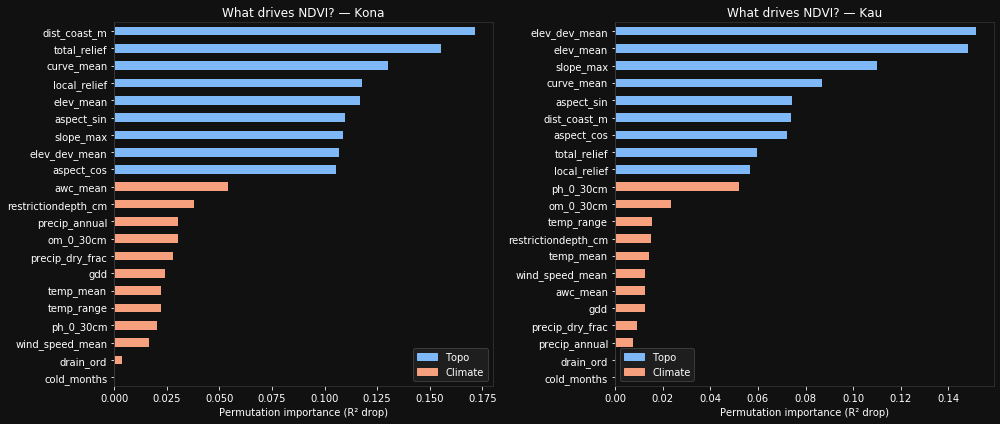

In [4]:
# ── Permutation importance: Kona vs Ka'u ─────────────────────────────────────
imps = {}
for reg in ['kona', 'kau']:
    sub = region_dfs[reg]
    X   = sub[FEAT_COLS].values
    y   = sub['ndvi_median'].values
    Xs  = scalers[reg].transform(X)
    perm = permutation_importance(rfs[reg], Xs, y, n_repeats=20, random_state=42)
    imps[reg] = pd.Series(perm.importances_mean, index=FEAT_COLS)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

for ax, reg in zip(axes, ['kona', 'kau']):
    imp = imps[reg].sort_values()

    ax.set_facecolor(BG)
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

    colors = ['#7eb8f7' if i < len(TOPO_COLS) else '#f7a07e'
              for i in [FEAT_COLS.index(f) for f in imp.index]]
    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
    ax.axvline(0, color='#555555', linewidth=0.8)
    ax.set_xlabel('Permutation importance (R² drop)', color='#222222')
    ax.set_title(f'What drives NDVI? — {reg.capitalize()}', color='#222222', fontsize=12)
    ax.xaxis.label.set_color('#222222')

    patches = [mpatches.Patch(color='#7eb8f7', label='Topo'),
               mpatches.Patch(color='#f7a07e', label='Climate')]
    _leg = ax.legend(handles=patches, facecolor='white', edgecolor='#cccccc')
    for _t in _leg.get_texts(): _t.set_color('#222222')

plt.tight_layout()
plt.savefig(f'{IMG}/09_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


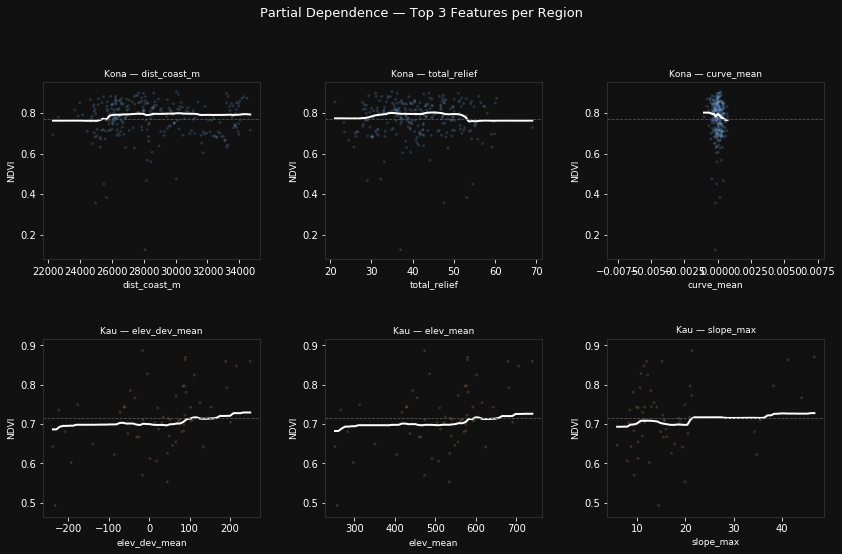

In [5]:
# ── Partial dependence: top 3 features per region ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8),
                         gridspec_kw={'hspace':0.45,'wspace':0.3})
fig.patch.set_facecolor(BG)

region_colors = {'kona': '#7eb8f7', 'kau': '#f7a07e'}

for row_idx, reg in enumerate(['kona', 'kau']):
    sub  = region_dfs[reg]
    X    = sub[FEAT_COLS].values
    y    = sub['ndvi_median'].values
    Xs   = scalers[reg].transform(X)
    rf   = rfs[reg]
    sc   = scalers[reg]
    top3 = imps[reg].sort_values(ascending=False).head(3).index.tolist()
    color = region_colors[reg]

    for col_idx, feat in enumerate(top3):
        ax = axes[row_idx, col_idx]
        fi = FEAT_COLS.index(feat)

        x_vals = np.linspace(Xs[:, fi].min(), Xs[:, fi].max(), 60)
        X_pdp  = np.tile(Xs.mean(axis=0), (60, 1))
        X_pdp[:, fi] = x_vals
        y_pdp  = rf.predict(X_pdp)
        x_orig = x_vals * sc.scale_[fi] + sc.mean_[fi]

        ax.set_facecolor(BG)
        ax.tick_params(colors='#222222')
        for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

        ax.scatter(sub[feat], y, alpha=0.2, s=8, color=color, edgecolors='none')
        ax.plot(x_orig, y_pdp, color='#222222', linewidth=2)
        ax.axhline(y.mean(), color='#555555', linewidth=0.8, linestyle='--')
        ax.set_xlabel(feat, color='#222222', fontsize=9)
        ax.set_ylabel('NDVI', color='#222222', fontsize=9)
        ax.set_title(f'{reg.capitalize()} — {feat}', color='#222222', fontsize=9)

fig.suptitle('Partial Dependence — Top 3 Features per Region', color='#222222', fontsize=13, y=1.01)
plt.savefig(f'{IMG}/09_pdp.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


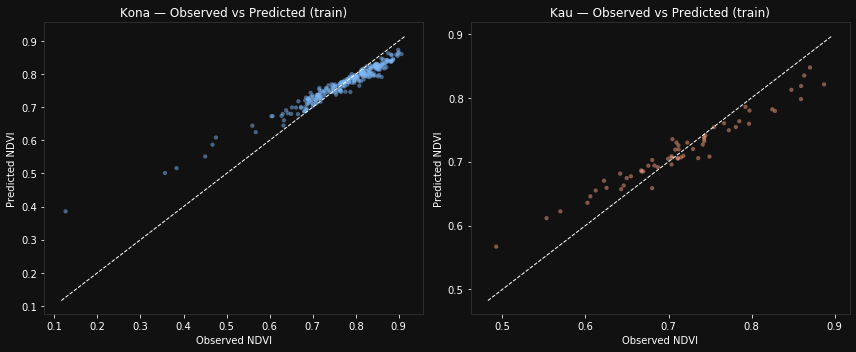

In [6]:
# ── Predicted vs actual (train fit) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)

for ax, reg in zip(axes, ['kona', 'kau']):
    y      = region_dfs[reg]['ndvi_median'].values
    y_pred = preds[reg]

    ax.set_facecolor(BG)
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

    color = '#7eb8f7' if reg == 'kona' else '#f7a07e'
    ax.scatter(y, y_pred, alpha=0.5, s=18, color=color, edgecolors='none')
    lims = [min(y.min(), y_pred.min())-0.01, max(y.max(), y_pred.max())+0.01]
    ax.plot(lims, lims, '--', color='#222222', linewidth=1)
    ax.set_xlabel('Observed NDVI', color='#222222')
    ax.set_ylabel('Predicted NDVI', color='#222222')
    ax.set_title(f'{reg.capitalize()} — Observed vs Predicted (train)', color='#222222', fontsize=12)

plt.tight_layout()
plt.savefig(f'{IMG}/09_pred_vs_actual.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


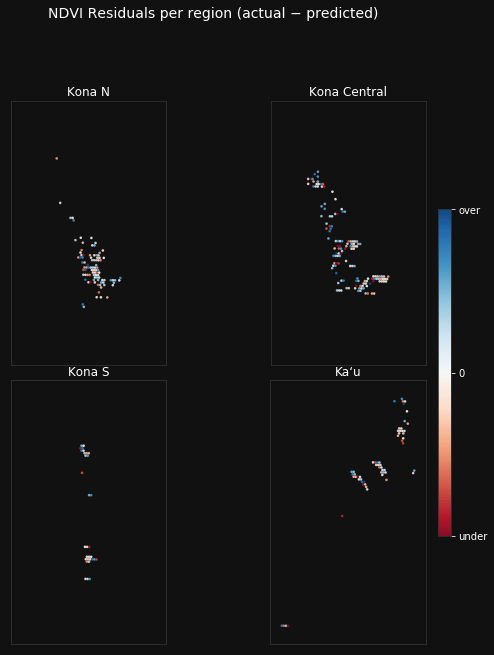

In [7]:
# ── Spatial residuals map ─────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS')

grid = pd.read_pickle(f'{DATA}/polygons/kona_grid.pkl')

resid_rows = []
for reg in ['kona', 'kau']:
    sub = region_dfs[reg].copy()
    sub['ndvi_resid'] = sub['ndvi_median'].values - preds[reg]
    resid_rows.append(sub[['plot_id', 'ndvi_resid']])

resid_df  = pd.concat(resid_rows).reset_index(drop=True)
gdf_res   = gpd.GeoDataFrame(grid.merge(resid_df, on='plot_id'),
                              geometry='geometry', crs='EPSG:4326')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    cx = gdf_res.geometry.centroid.x
    cy = gdf_res.geometry.centroid.y

kona    = gdf_res[cx < SPLIT_LON]
kau     = gdf_res[cx >= SPLIT_LON]
kona_cy = cy[kona.index]
lat_min, lat_max = kona_cy.min(), kona_cy.max()
cut1 = lat_min + (lat_max - lat_min) / 3
cut2 = lat_min + 2 * (lat_max - lat_min) / 3
kona_n = kona[kona_cy >= cut2]
kona_m = kona[(kona_cy >= cut1) & (kona_cy < cut2)]
kona_s = kona[kona_cy < cut1]

ab = kau.total_bounds
span_w = (ab[2]-ab[0]) * 1.15
span_h = (ab[3]-ab[1]) * 1.15

def centroid_b(r):
    b = r.total_bounds; return (b[0]+b[2])/2, (b[1]+b[3])/2

panels = [(kona_n,'Kona N'),(kona_m,'Kona Central'),(kona_s,'Kona S'),(kau,"Kaʻu")]
vabs   = gdf_res['ndvi_resid'].abs().quantile(0.95)
cmap_r = clip_cmap('RdBu', lo=0.05, hi=0.95)

fig, axes = plt.subplots(2, 2, figsize=(11, 10),
                         gridspec_kw={'hspace':0.06,'wspace':0.04})
fig.patch.set_facecolor(BG)

for ax, (region, label) in zip(axes.flat, panels):
    rx, ry = centroid_b(region)
    ax.set_facecolor(BG)
    region.plot(ax=ax, column='ndvi_resid', cmap=cmap_r,
                vmin=-vabs, vmax=vabs, legend=False, edgecolor='none', alpha=0.9)
    ax.set_xlim(rx-span_w/2, rx+span_w/2)
    ax.set_ylim(ry-span_h/2, ry+span_h/2)
    ax.set_title(label, fontsize=12, pad=5, color='#222222')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

sm = plt.cm.ScalarMappable(cmap=cmap_r, norm=plt.Normalize(vmin=-vabs, vmax=vabs))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, aspect=25)
cbar.set_ticks([-vabs, 0, vabs])
cbar.set_ticklabels(['under', '0', 'over'])
cbar.ax.yaxis.set_tick_params(color='#222222')
for _t in cbar.ax.yaxis.get_ticklabels(): _t.set_color('#222222')
cbar.outline.set_edgecolor('#333333')
fig.suptitle('NDVI Residuals per region (actual − predicted)', color='#222222', fontsize=14, y=1.01)
plt.savefig(f'{IMG}/09_ndvi_residuals.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
